# Exercise project 1


### <i>Dataset evaluation report </i>

<i>Lecture example</i>

---

### Summary

|Topic               |Description               |
|--------------------|--------------------------|
|Dataset Name:       | Seattle House Sales Prices                         |
|Dataset Link:       |  https://www.kaggle.com/datasets/sameersmahajan/seattle-house-sales-prices                        | 
|Target Variable:    | price                         | 
|Type of Dataset:    | Regression|

<br>



---


## Overview

<br>
<br>

##### <b> <u>Step 1a</u>: Inspect the datatypes for each column </b> 

<i>
<strong style='color:orange ; background-color:black;'>Fix these before continuing below.</strong>


Some visuals require numeric/datetime columns (heatmaps, matrices, etc). Most common problem is date-columns being in string/object -format => change to DateTime -objects.
</i>

<i>Easiest option is probably to use pandas' dtypes-feature.</i>
<br>

<hr>

The date-column was in object -format, changed it to DateTime for further processing.

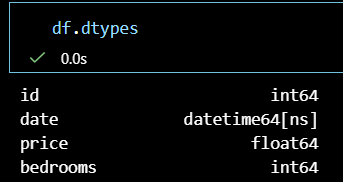

##### <b> <u>Step 1b</u>: Inspect the shape of the dataset (the number of rows and columns.) </b> 

<i>


How many rows and columns are in your dataset? 

Are you expecting any issues if you were to train a model with this amount of rows/columns?

Justify your answer. Provide visuals if needed.

<br>

<u><b>Hint:</b></u> ydata-profiling, pandas.shape()

</i>



<hr>

Number of variables	22<br>
Number of observations	21613

You can also analyze below if this is sufficient for ML or analysis purposes.

##### <b> <u>Step 1c</u>: Inspect NaN values, duplicates, zeroes, invalid/nonsensical/problematic values </b> 

<i>
How many missing values are there? 
<br>

How many duplicate values are there? 

Are there any abnormal amounts of zeroes?

Are there any values which don't make sense or don't belong there?

Please explain how each of these values in your dataset might or might not be problematic.

<br>

<u><b>Hint:</b></u> ydata-profiling, pandas


</i>


<hr>

No duplicates or missing values. All values seem normal or believable in this dataset.

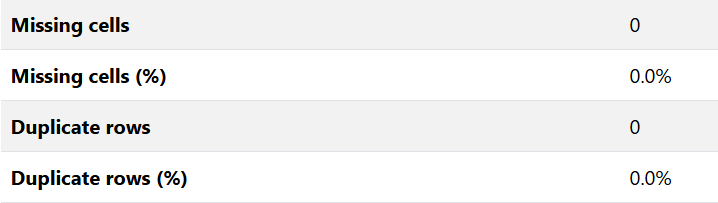

Houses are between USD 75k$ - 7.7 million USD.

##### <b> <u>Step 1d</u>: Are there any alerts recommendations?</b> 

<i>
When you used a big-picture tool(s), what kind of alerts did it give you? Were they valid concerns?

<br>

Justify. If possible, please show a visual.

<br>

<u><b>Hint:</b></u> ydata-profiling, SweetViz, AutoViz, dataprep etc.
</i>

<hr>

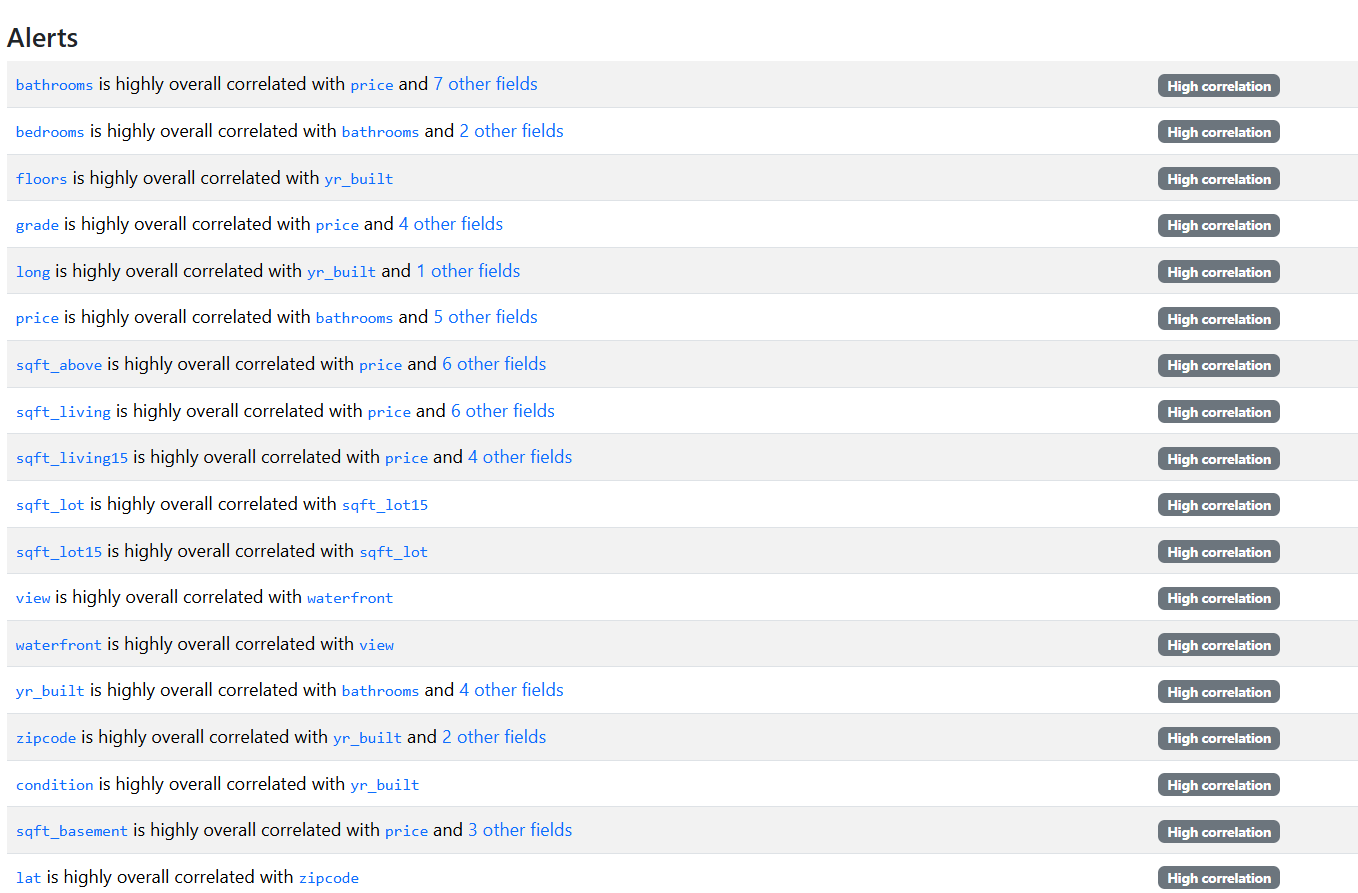

ydata is quite sensitive to high correlations (attempting to imply redundancy), but you have to study carefully each variable.

Considerable redundancy with correlations are probably with square footage -variables, since they contain a lot of same information (above, total, basement square footage etc.).

Target variable usually needs to correlate at least something in order to be useful in ML context.

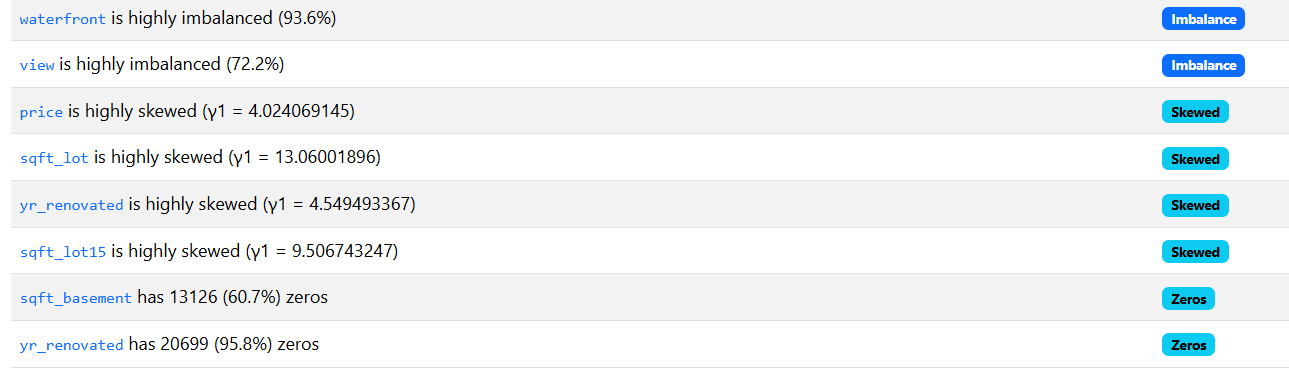

Waterfront and view are considerably imbalanced, this might be a problem in the dataset (need to address/optimize) later.

Some skewness is present in some variables, usually right skewed (beta distribution).

Also, ydata is correctly detecting zeroes in basement and renovation -variables.

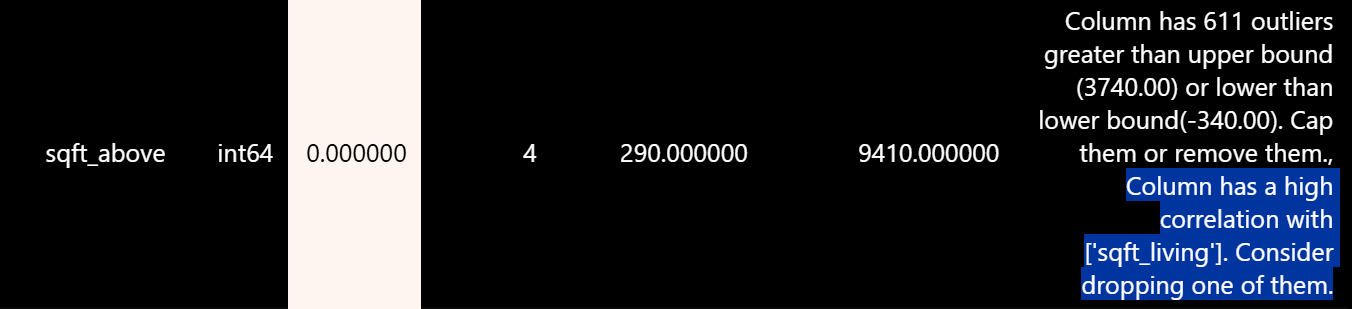

AutoViz also implies high redundancy in square footage variables.

---

## Distribution, outliers, imbalances

<br>
<br>

##### <b> <u>Step 2a</u>: Distributions & imbalances</b> 

<i>
Inspect the distribution for the target variable and its features. 
<br>

Which columns may have distributions which are problematic for machine learning? 
<br>

For each problematic column, describe what kind of problems they exhibit (for example: left-skewed, right-skewed, high kurtosis, low kurtosis).

Do you expect this will be an issue when training ML models? Justify your answers. Please introduce visuals.

 <br>

<u>OPTIONAL:</u> 

Q-Q plots. Another way to visualize distributions is using Q-Q plots. 

These are particularly good for identifying thin/thick-tailed distributions and are an alternative to histograms. 

Do these phenomena exist in your dataset?  

<br>

<u><b>Hint:</b></u> ydata, SweetViz, Dtale, pandas…



</i>


<br><br>
<br>

**Target variable distribution**

Target variable (price) distribution. Not quite normal distribution, some outliers in the high end. Since this is the target variable in a regression dataset, we should keep this in mind while training a ML model. Most likely we'll have to use a transformation algorithm in order to improve performence (e.g. Log, Box-Cox, Yeo-Johnson, Quantile transformation etc.)

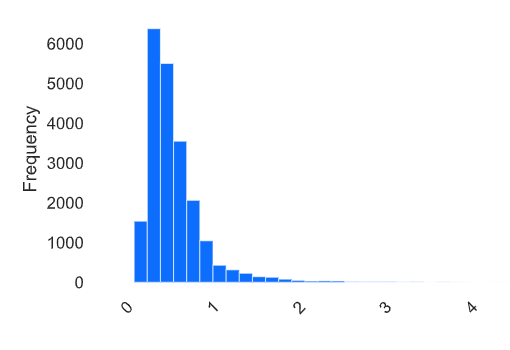

**Support variable distributions**

Note from instructor: SUpport variables are usually not as sensitive on being a normal distribution (or uniform distribution in some cases). As long as the variable has good predictive power (we'll study SHAP/LIME later), the distribution can be good. However, if the prediction power is not good, consider optimizing support variable distributions as well.

bathrooms have a sporadic distribution, which is partially due to the system used in US (e.g. 2.5 bathrooms => 2 full bathrooms (including shower/bathtub) etc.) and 1 bathroom with only the toilet and sink (0.5 bathrooms). This variable is probably good to keep in mind if we need to simplify the data structure for an easier distribution. 

Then again, this is probably a very realistic distribution (most houses have either 1 or 2.5 bathrooms).

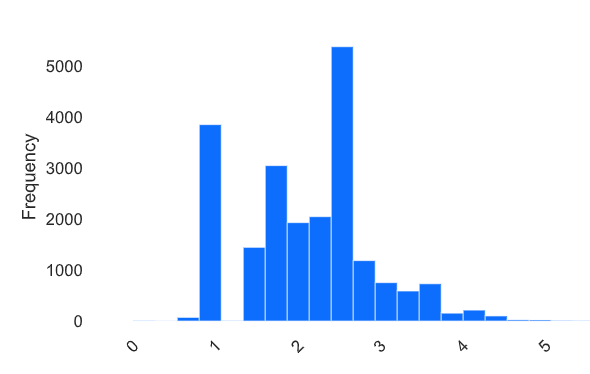

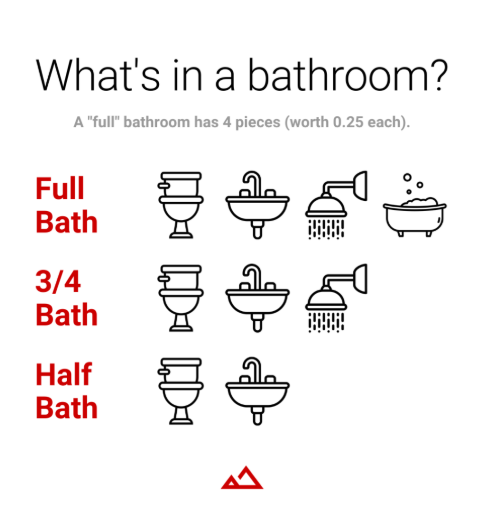

Image source: https://danmccurley.com/wp-content/uploads/bathroom-infographic-1024x1024.png

Due to the bathroom calculation system shown above, we probably don't want to remove the decimals from this variable. 

*bedrooms* are quite heavily concentrated, most values being 2-5 bedrooms.  This variable might need simplification and/or outlier removal. Probably a good idea to check this balance again after the outliers in the target variable have been removed. 

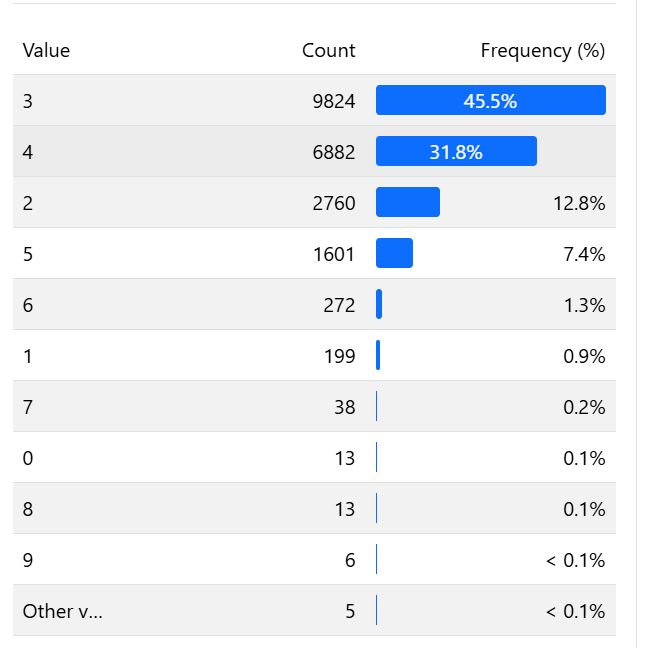

*sqft_living* is almost normal distribution, only slightly skewed and small amount of potential outliers in the high end. MIght need some outlier removal or other methods (like distribution management) to adjust the distribution (if nothing else works, remember: it's usually a good idea to preserve as much of the original data as possible).

We can also probably assume the larger buildings belong to the most expensive buildings, so after removing the outliers based on the price, we probably lose many of the larger houses.

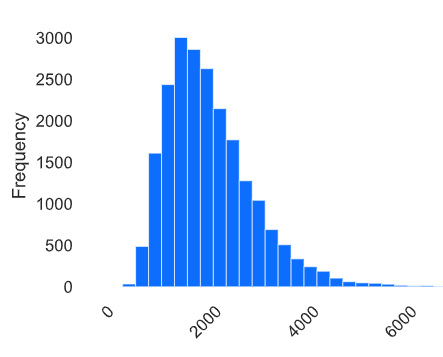

The grade variable has a rough normal distribution, it seems grade values 7-9 are the most common ones. Note: the grade -variable in this dataset is one of the biggest factors when deciding the price of the house.

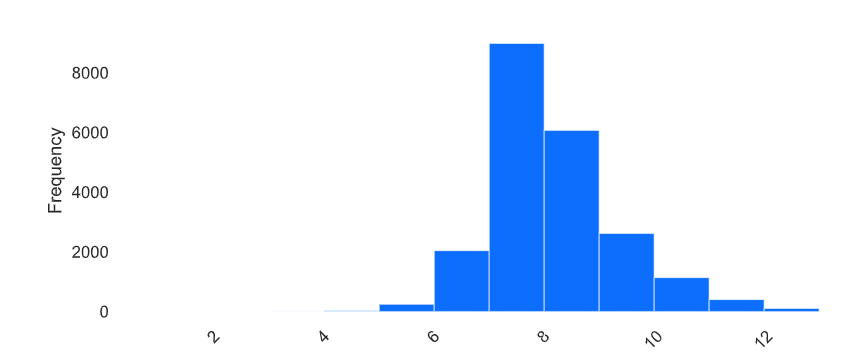

**Dataset imbalances**

Extremy imbalance in the waterfront and view -categories. However, this makes sense, since most houses are not next to body of water or have an extremely nice view. However, we might want to attempt using methods like synthetization to attempt to mitigate this. 

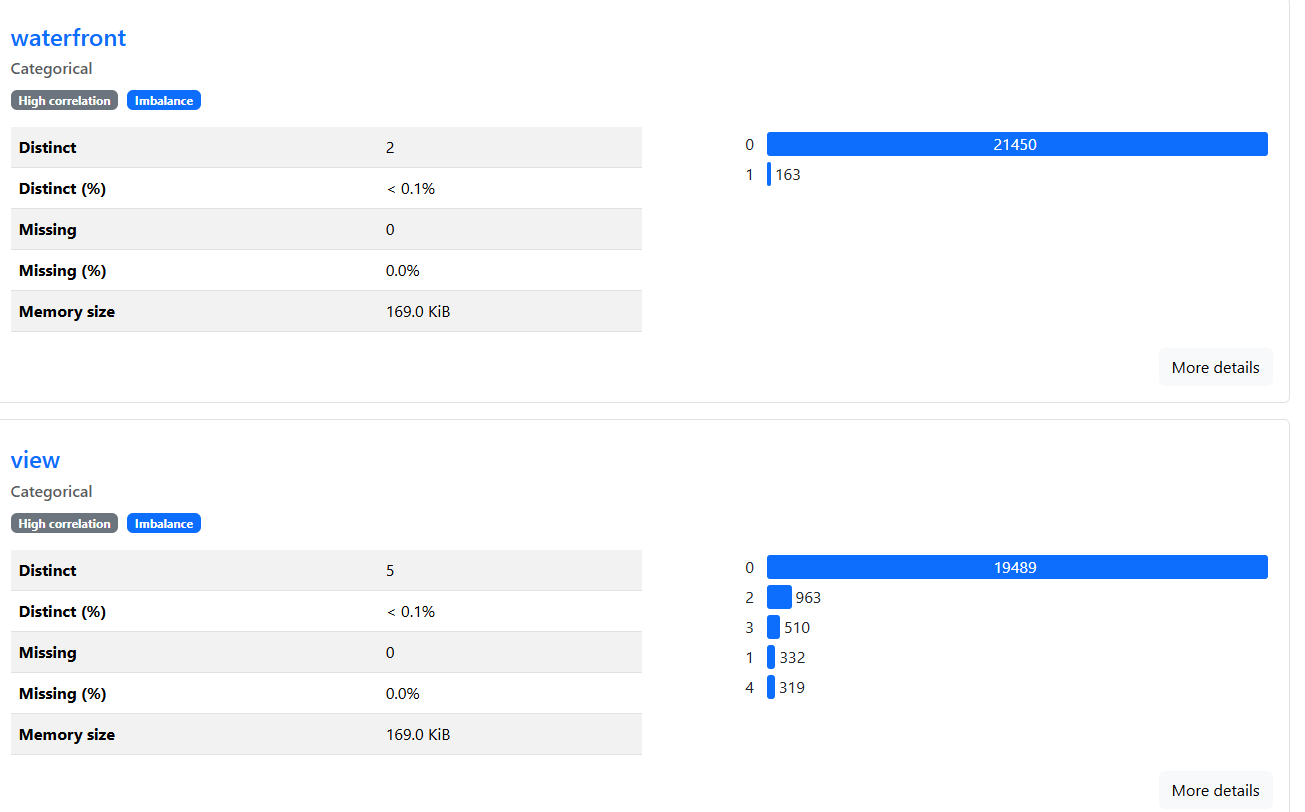

Also, under/oversampling -techniques can be considered .

TODO: Study also yr_built, floors, yr_renovated, sqft_basement

##### <b> <u>Step 2b</u>: Multicollinearity & redundancy </b> 

<i>
Some columns may prove to be redundant to others -- Or even worse, they give away the answer entirely.
    <br>

Are there any columns which are redundant and/or suggest high multi-collinearity? 

Which tool(s)/test(s) have you performed to come to this conclusion? 

Justify your answer and, if possible, produce your results as an image below.

<br>

<u><b>Hint:</b></u> VIF test, Correlation Matrix, Phik-matrix, RFE etc.

</i>


<br>
<br>
<br>

##### <b> <u>Step 2c</u>: High cardinality</b> 

<i>
Inspect each categorical column for high-cardinality (high percentage of unique values in the dataset). 

<br>

Which columns, if any, contain an unusual or problematic amount of unique values?  Which tool(s) or method(s) did you use to come to this conclusion? 

Justify your answer and, if possible, produce the output as a visual.

<br>

<u><b>Hint:</b></u> Big picture tool like ydata-profiling, pd.value_counts()

</i>


<br>
<br>
<br>
<br>

---

## Overlapping, noise, and correlation/associations

<br>
<br>

##### <b> <u>Step 3a</u>: Major trends</b> 

<i>
After inspecting the trends between your target variable and its features -- Are you noticing anything interesting?
<br>

 Any surprising positive or negative trends?
 
  Any evidence of noise (jittering)?
  
Are your interesting columns linear or non-linear?

Is there anything that 'breaks the rules' of the trend?
 
Please provide visuals of which major trends you found interesting and worthy mentioning.

Hypothesize and, if necessary, research online why this irregular trend occurs.

Also, provide which tool(s) you have used to inspect this aspect of your dataset.

<br>

<u><b>Hint:</b></u> regression plots/scatterplot/pairplot, correlations/phik-matrix/associations, feature importance tools ...

</i>


<br>
<br>
<br>

##### <b> <u>Step 3b</u>: Overlapping Data</b> 

<i>
Does any overlapping exist between the features and your target variable?
<br>

Do you expect this to be an issue if you were to train a model with this data?

Justify your answer and, if reasonably possible, provide visuals.

Also, provide which tool(s) you have used to inspect this aspect of your dataset.

<br>

<u><b>Hint:</b></u> seaborn box-/scatterplots
</i>

<br><br>
<br>

##### <b> <u>Step 3c</u>: Outliers & noise</b> 

<i>
Inspect each categorical column for potential outliers and noise. 

<br>

<u>For each column with noise:</u>

In which columns are you detecting noise? Which tool(s) or method(s) did you use to find this?


<u>For each column with outliers:</u>

Are you seeing many outliers in your columns? How extreme (in your opinion) are the outliers? How problematic do you expect this to be if these outliers remained in the dataset? Which tool(s) or method(s) did you use to find this?


<u><b>Hint:</b></u> Isolation Forest, IQR, z-score, Elliptic Envelope, MAD...




</i>


<br>
<br><br>

##### <b> <u>Step 3d</u>: Correlations & associations</b> 

<i>
Inspect the Phi-K and Correlations matrix.

<br>

What kind of linear relationships are you detecting that correlate with your target variable?
 
What kind of non-linear relationships are you detecting that associate with your target variable?

Do you suspect any noise and/or multi-collinearity from these results?

Are there any other interesting things you found?

Justify your answer and provide visuals of the output of both the phi-k and correlation matrix.

<br>

<u><b>Hint:</b></u> Phik/pd.corr + heatmap, or ydata with phik-support, SweetViz -associations, Dython ...


</i>


<br>
<br>
<br>

##### <b> <u>Step 3e</u>: Feature importances</b> 

<i>
Which features seem to be the most important to your target variable?

<br>

How did you come to this conclusion? 
 
Should any of the variables be removed/dropped, or do they need further processing?

<br>

<u><b>Hint:</b></u> Correlation + PhiK matrices, SelectKBest, Fisher Score, RFE ...

</i>


<br>
<br><br>

##### <b> <u>Step 3f</u>: Other potential problems or issues in the dataset? </b>

<i>
If you found anything else that is worth mentioning, and it isn’t found in the previous checklists, you can also elaborate on these for extra points.

<br>

This usually involves limitations in the datasets, weird behavior (e.g. doesn’t make sense from the common sense point of view) or something similar.



</i>

---

### Summary of findings


<i> Please summarize all of the major findings and issues here briefly. A paragraph or two is fine. Lists are also OK.

</i>

---

##  Advanced tasks (optional, but extra points)

<br>
<br>

##### <b> <u>Step 4a</u>: Under-representation of combinatory categories</b> 

<i>
Are there any combinations of values which are exceptionally rare?

<br>

Example: A client for a bank might have a 18 year old customer with a 23 million Euro outstanding balance. 

Why are they rare? Do you expect these to be problematic? Could they be removed with minor repercussions?

<u><b>Hint:</b></u> Apriori

</i>

<br>
<br><br>

##### <b> <u>Step 4b</u>: Feature creation & derived features</b>

<i>
Can you combine features using operations (+, -, /, *) to make them more useful?

<br>

 Which features would you combine, how, and why?

Example: Credit lenders & debt / income ratio.
Example: Measurable speed – Km / hour

<br>

<u><b>Hint:</u></b> Sometimes, there just isn’t a clear combination of features that makes sense to add to your dataset. However, this problem is mitigated by other tools later in the course.


</i>

<br>
<br><br>

##### <b> <u>Step 4c</u>: Trends between features</b> 

<i>

What can you find when looking at the trends between the features of your dataset?
<br>

Are you noticing some interesting connections and trends?

Could there be some hidden value behind certain features that a machine learning model might find hard to see?
 
<br>

<u><b>Example:</b></u> House condition --> House quality -->  Price

<br>

Does any redundancy exist between these features?

Do you believe this trend would make a negative impact on your model?

Please show visuals of the most interesting feature-feature trends (scatterplot, regplot)

Which tool(s) did you use to inspect this?

<br>

<u><b>Hint:</b></u> You will find these especially (but are not limited to) in time-series data. Seaborn.regplots with hue are really useful here

<br>
<br><br>

</i>

##### <b><u>Step 4d</u>: Conventional EDA vs. tools </b>

<i>
Verify that the results in the tools are correct by using the conventional data-analytics skillset in Python. 

<br>

Use manual EDA (Exploratory Data Analysis), or in other words, <u>all the previous skills you have learnt in earlier data analytics studies.</u>

Verify with pandas features and seaborn visualizations and make sure the analysis of these tools are actually correct.

Are there any contradictions between the the new tools you've used and your own analysis?

<br><br>


##### <b> <u>Step 4e</u>: Non-linear connections / polynomial trends </b>

<i>
One of the features the evaluation tools have difficulties with is visualizing any non-linear connections in a dataset.

<br>

Seaborn, and its regression plot function, has a feature that supports polynomial regression as well.

For the most complicated pairs of variables, try using polynomial regression plots in your dataset and analyze the amount of noise, outliers and complexity your data might have.

</i>